import required library packages

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

read file

In [59]:
df=pd.read_csv("data/stud.csv")

In [60]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [61]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [62]:
df[df.duplicated()]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [64]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [65]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Exploring Data

In [66]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [67]:
print("categories in  gender ",end=" ")
print(df['gender'].unique())
print("categories in  race/ethnicity ",end=" ")
print(df['race/ethnicity'].unique())
print("categories in  parental level of education ",end=" ")
print(df['parental level of education'].unique())
print("categories in  lunch ",end=" ")
print(df['lunch'].unique())
print("categories in  test preparation course ",end=" ")
print(df['test preparation course'].unique())

categories in  gender  ['female' 'male']
categories in  race/ethnicity  ['group B' 'group C' 'group A' 'group D' 'group E']
categories in  parental level of education  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in  lunch  ['standard' 'free/reduced']
categories in  test preparation course  ['none' 'completed']


In [68]:
numerical_features=[feature for feature in df.columns if df[feature].dtypes!="O"]
categorical_features=[feature for feature in df.columns if df[feature].dtypes=="O"]
print("we have {} numerical features :{}".format(len(numerical_features),numerical_features))
print("we have {} categorical features :{}".format(len(categorical_features),categorical_features))

we have 3 numerical features :['math score', 'reading score', 'writing score']
we have 5 categorical features :['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


Adding columns for "Total Score" and "Average"

In [69]:
df["total score"]=df['math score']+df["reading score"]+df["writing score"]
df["average score"]=df["total score"]/3

In [70]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [71]:
writing_score_100=df[df["writing score"]==100]["average score"].count()
reading_score_100=df[df["reading score"]==100]["average score"].count()
math_score_100=df[df["math score"]==100]["average score"].count()

print("number of students who get centum in writing exam is ",writing_score_100)
print("number of students who get centum in reading exam is ",reading_score_100)
print("number of students who get centum in math exam is ",math_score_100)

number of students who get centum in writing exam is  14
number of students who get centum in reading exam is  17
number of students who get centum in math exam is  7


In [72]:
writing_less_20=df[df["writing score"]<=20]["average score"].count()
reading_less_20=df[df["reading score"]<=20]["average score"].count()
math_less_20=df[df["math score"]<=20]["average score"].count()
print("number of students who get less than 20 in writing exam is ",writing_less_20)
print("number of students who get less than 20 in reading exam is ",reading_less_20)
print("number of students who get less than 20 in math exam is ",math_less_20)

number of students who get less than 20 in writing exam is  3
number of students who get less than 20 in reading exam is  1
number of students who get less than 20 in math exam is  4


### exploratory data analytics

 Histogram & KDE

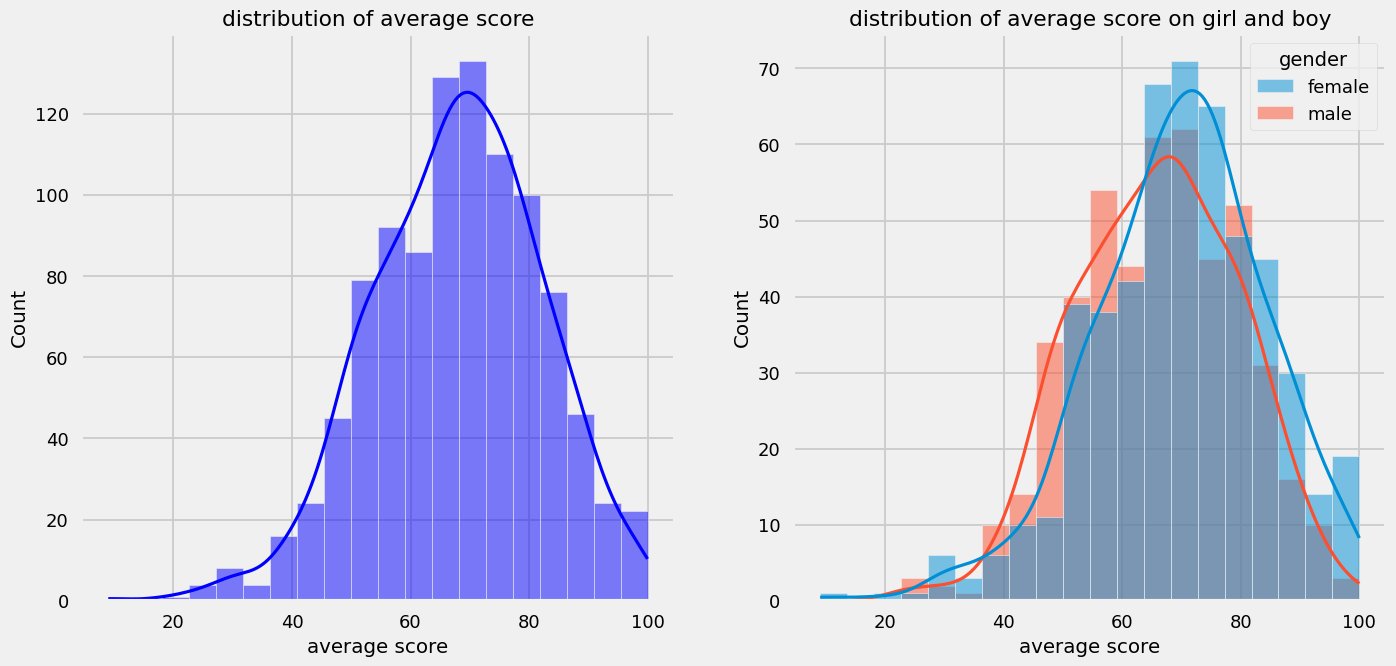

In [73]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x="average score",kde=True,color="blue",bins=20)
plt.title("distribution of average score")
plt.subplot(122)
sns.histplot(data=df,x="average score",bins=20,hue="gender",kde=True)
plt.title("distribution of average score on girl and boy")
plt.show()

### insights
females tends to perform well then male

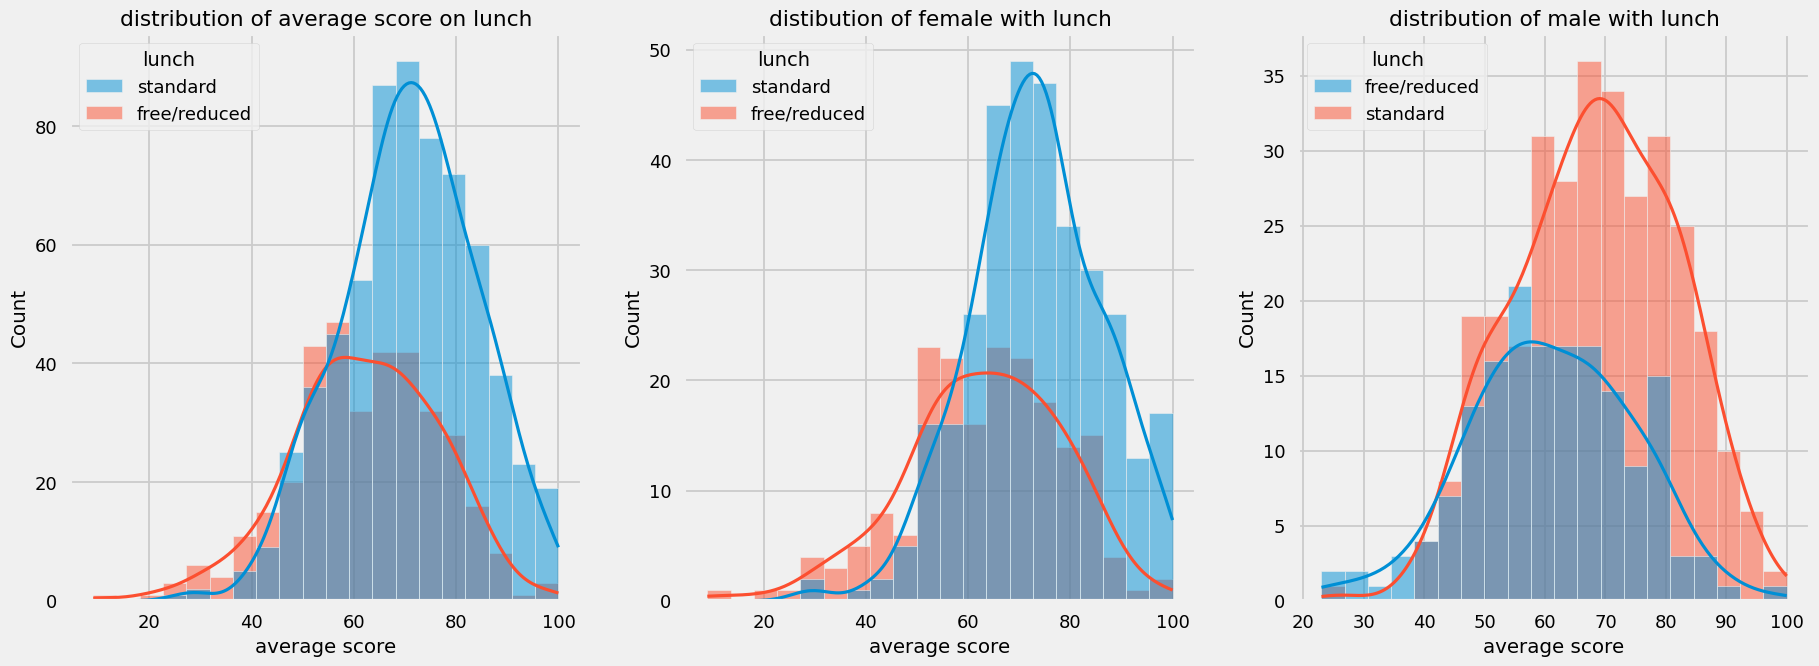

In [74]:
fig,axs=plt.subplots(1,3,figsize=(20,7))
plt.subplot(131)
sns.histplot(data=df,x="average score",hue="lunch",kde=True,color="blue",bins=20)
plt.title("distribution of average score on lunch")
plt.subplot(132)
sns.histplot(data=df[df.gender=="female"],x="average score",hue="lunch",kde=True,color="blue",bins=20)
plt.title("distibution of female with lunch")
plt.subplot(133)
sns.histplot(data=df[df.gender=="male"],x="average score",hue="lunch",kde=True,color="blue",bins=20)
plt.title("distribution of male with lunch")
plt.show()

### insights
1. standard lunch help to perform well in exam
2. standard lunch help perform well in exam be a female
3. standard lunch help perform well in exam be a male also

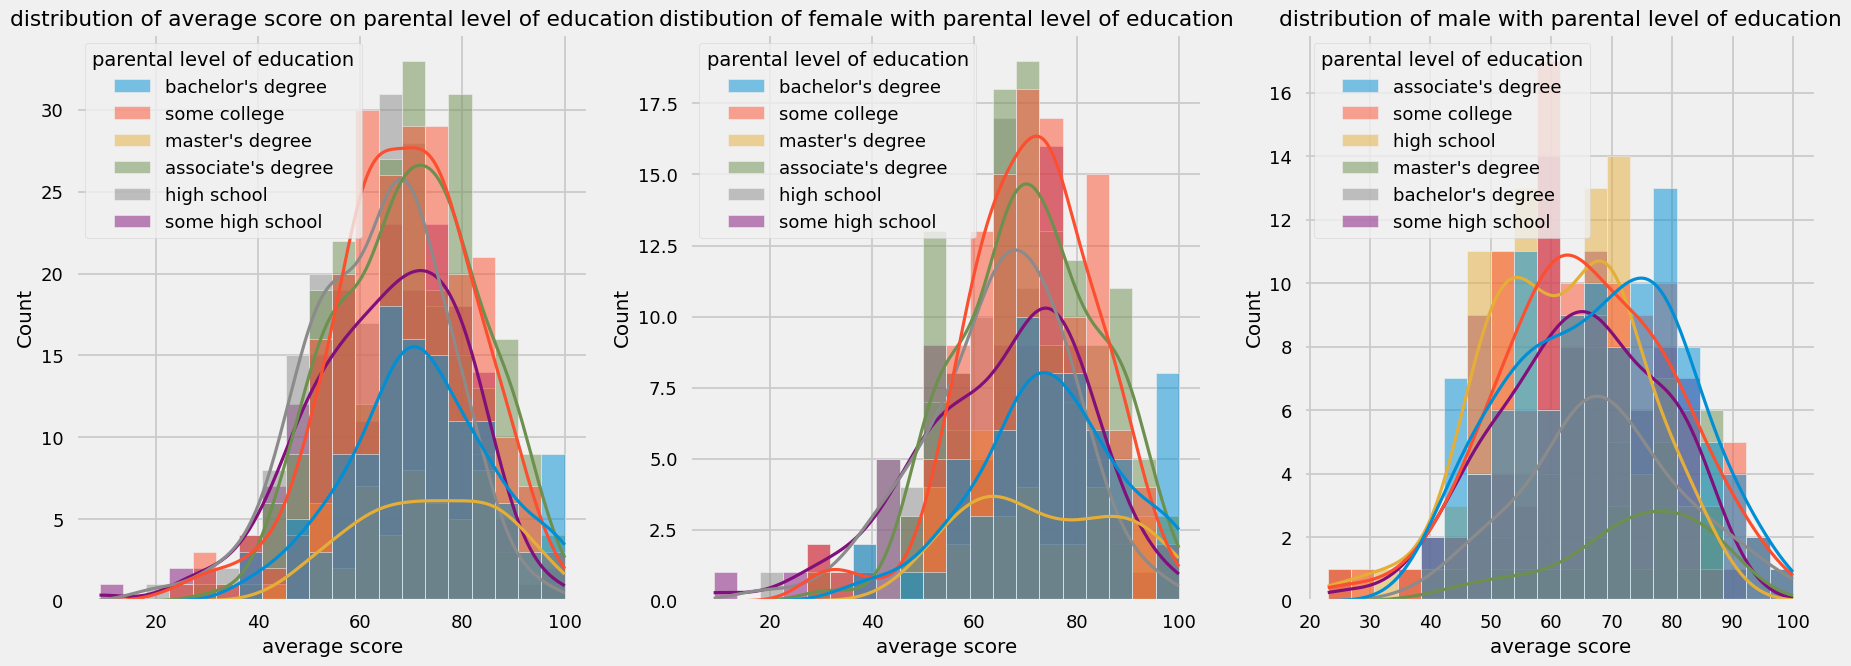

In [75]:
fig,axs=plt.subplots(1,3,figsize=(20,7))
plt.subplot(131)
sns.histplot(data=df,x="average score",hue="parental level of education",kde=True,color="blue",bins=20)
plt.title("distribution of average score on parental level of education")
plt.subplot(132)
sns.histplot(data=df[df.gender=="female"],x="average score",hue="parental level of education",kde=True,color="blue",bins=20)
plt.title("distibution of female with parental level of education")
plt.subplot(133)
sns.histplot(data=df[df.gender=="male"],x="average score",hue="parental level of education",kde=True,color="blue",bins=20)
plt.title("distribution of male with parental level of education")
plt.show()

### insights
1. plot 1 more students at 60-80 score range,master's degree and bachelor's degree,some college parental education increace performance of students.
2. plot 2 more female students score higher score than males,master's and associated,bachelor's degree parental education level students has higher score.more females students at 60-90 range.
3. plot 3 more males students score at 50-80 range

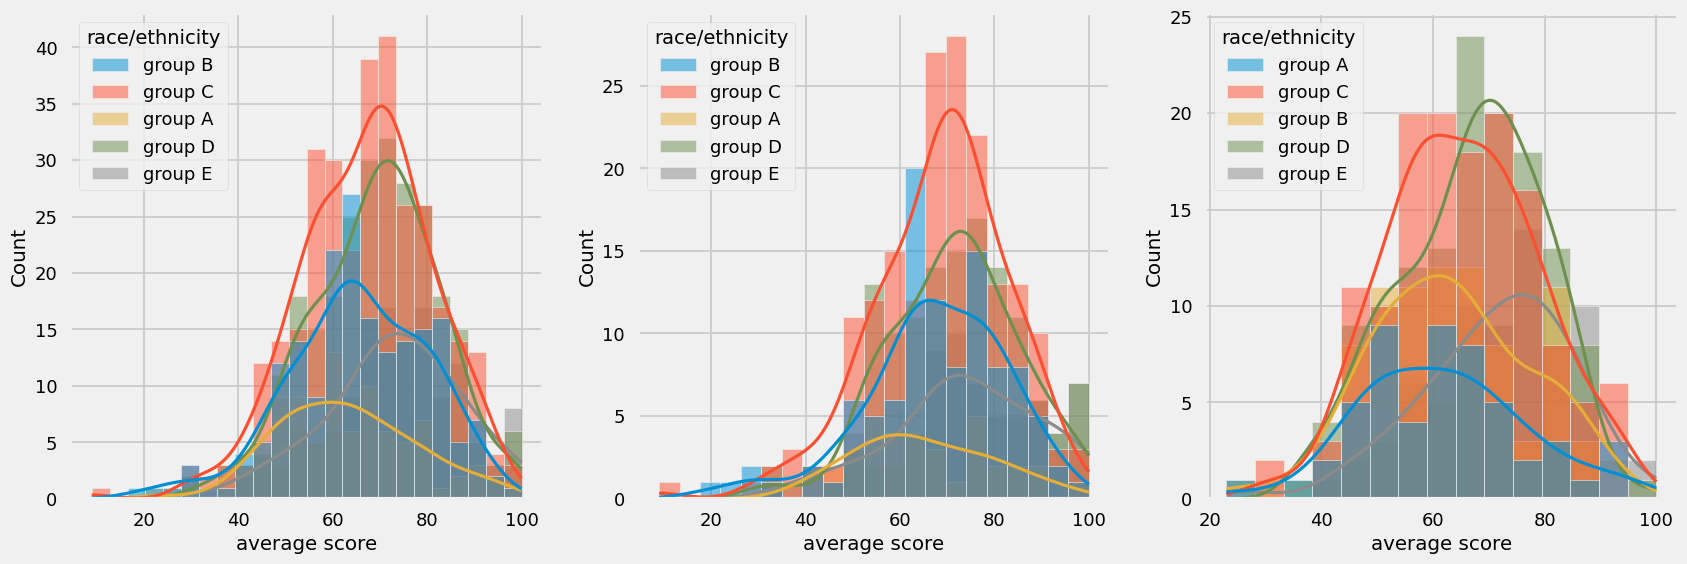

In [76]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average score',kde=True,hue='race/ethnicity')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='female'],x='average score',kde=True,hue='race/ethnicity')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='male'],x='average score',kde=True,hue='race/ethnicity')
plt.show()

### insights
1.  plot 1 : group C,D,E perform well on exam,A and B performs poor
2.  plot 2 : also group C,D,E perform well on exam,A and B performs poor
3.  plot 3 : group D,E perform well on exam,A ,B,C  performs poor
4.  overall group E is best performers

Maximumum score of students in all three subjects

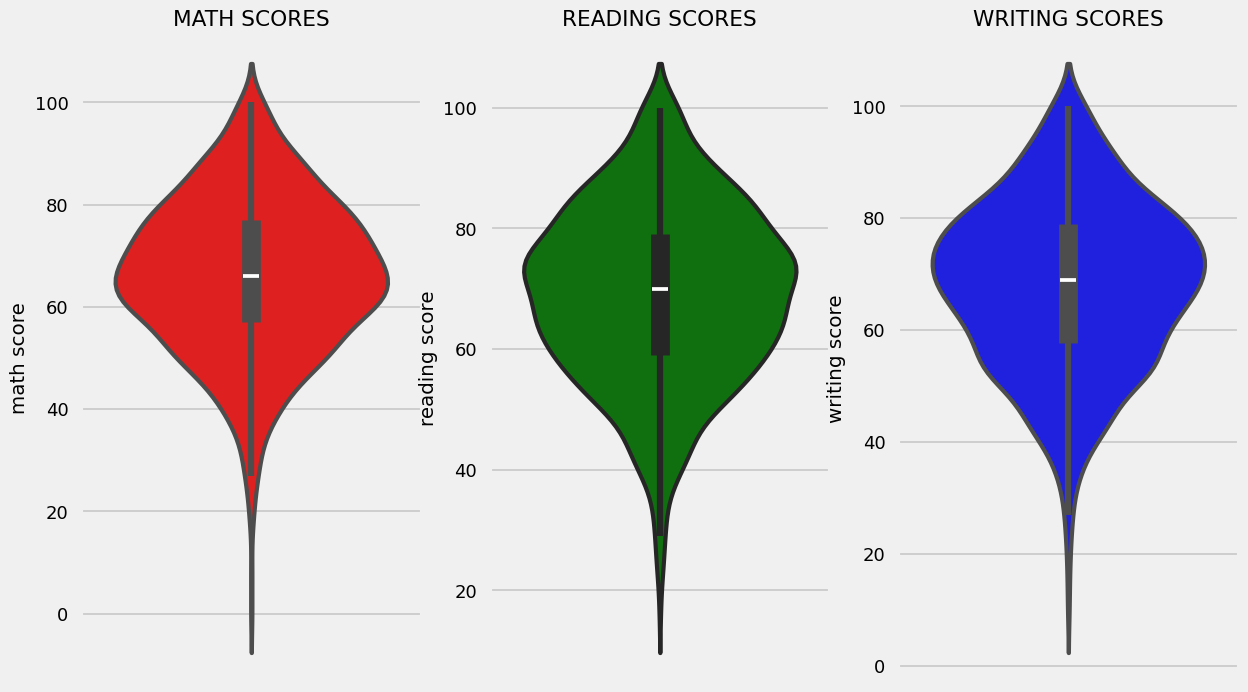

In [77]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score',data=df,color='blue',linewidth=3)
plt.show()

### insights

all above plot shows that in math score of student in range on 60-70 ,score in reading aand writing is 70-80 range

### **Multivariate analysis using pieplot**

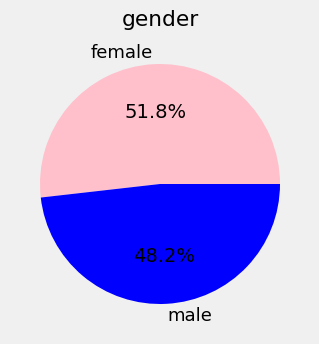

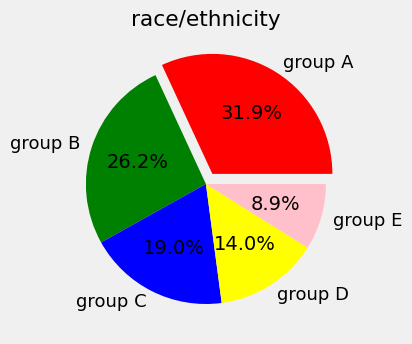

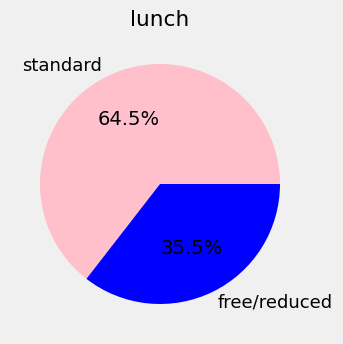

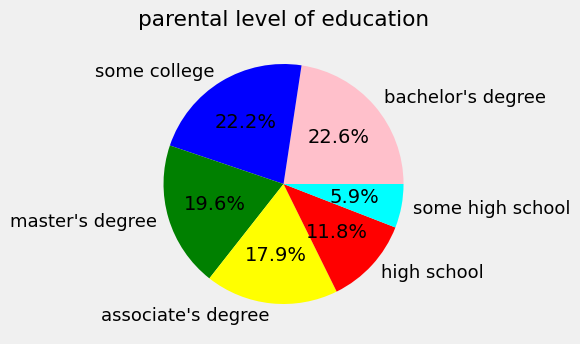

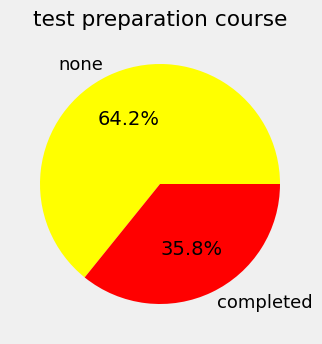

In [78]:
plt.rcParams['figure.figsize']=(20,6)
plt.subplot(1,5,1)
label=["female","male"]
values=df["gender"].value_counts()
color=["pink","blue"]
plt.pie(values,labels=label,autopct="%1.1f%%",colors=color)
plt.title("gender")
plt.show()

plt.subplot(1,5,2)
label1=["group A","group B","group C","group D","group E"]
values1=df["race/ethnicity"].value_counts()
color1=["red","green","blue","yellow","pink"]
plt.pie(values1,labels=label1,autopct="%1.1f%%",colors=color1,explode=(0.1,0,0,0,0))
plt.title("race/ethnicity")
plt.show()

plt.subplot(1,5,3)
label2=['standard','free/reduced']
values2=df["lunch"].value_counts()
color2=["pink","blue"]
plt.pie(values2,labels=label2,autopct="%1.1f%%",colors=color2)
plt.title("lunch")
plt.show()


plt.subplot(1,5,4)
label3=["bachelor's degree" ,'some college' ,"master's degree" ,"associate's degree","high school","some high school"]
values3=df["parental level of education"].value_counts()
color3=["pink","blue","green","yellow","red","cyan"]
plt.pie(values3,labels=label3,autopct="%1.1f%%",colors=color3)
plt.title("parental level of education")
plt.show()

plt.subplot(1,5,5)
label4=['none' ,'completed']
values4=df["test preparation course"].value_counts()
color4=["yellow","red"]
plt.pie(values4,labels=label4,autopct="%1.1f%%",colors=color4)
plt.title("test preparation course")
plt.show()


### Insights
1. Number of Male and Female students is almost equal
2. Number students are greatest in Group A
3. Number of students who have standard lunch are greater
4. Number of students who have not enrolled in any test preparation course is greater
5. Number of students whose parental education is "bachelor's degree " is greater followed closely by "some collge"

Feature Wise Visualization

GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?


UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

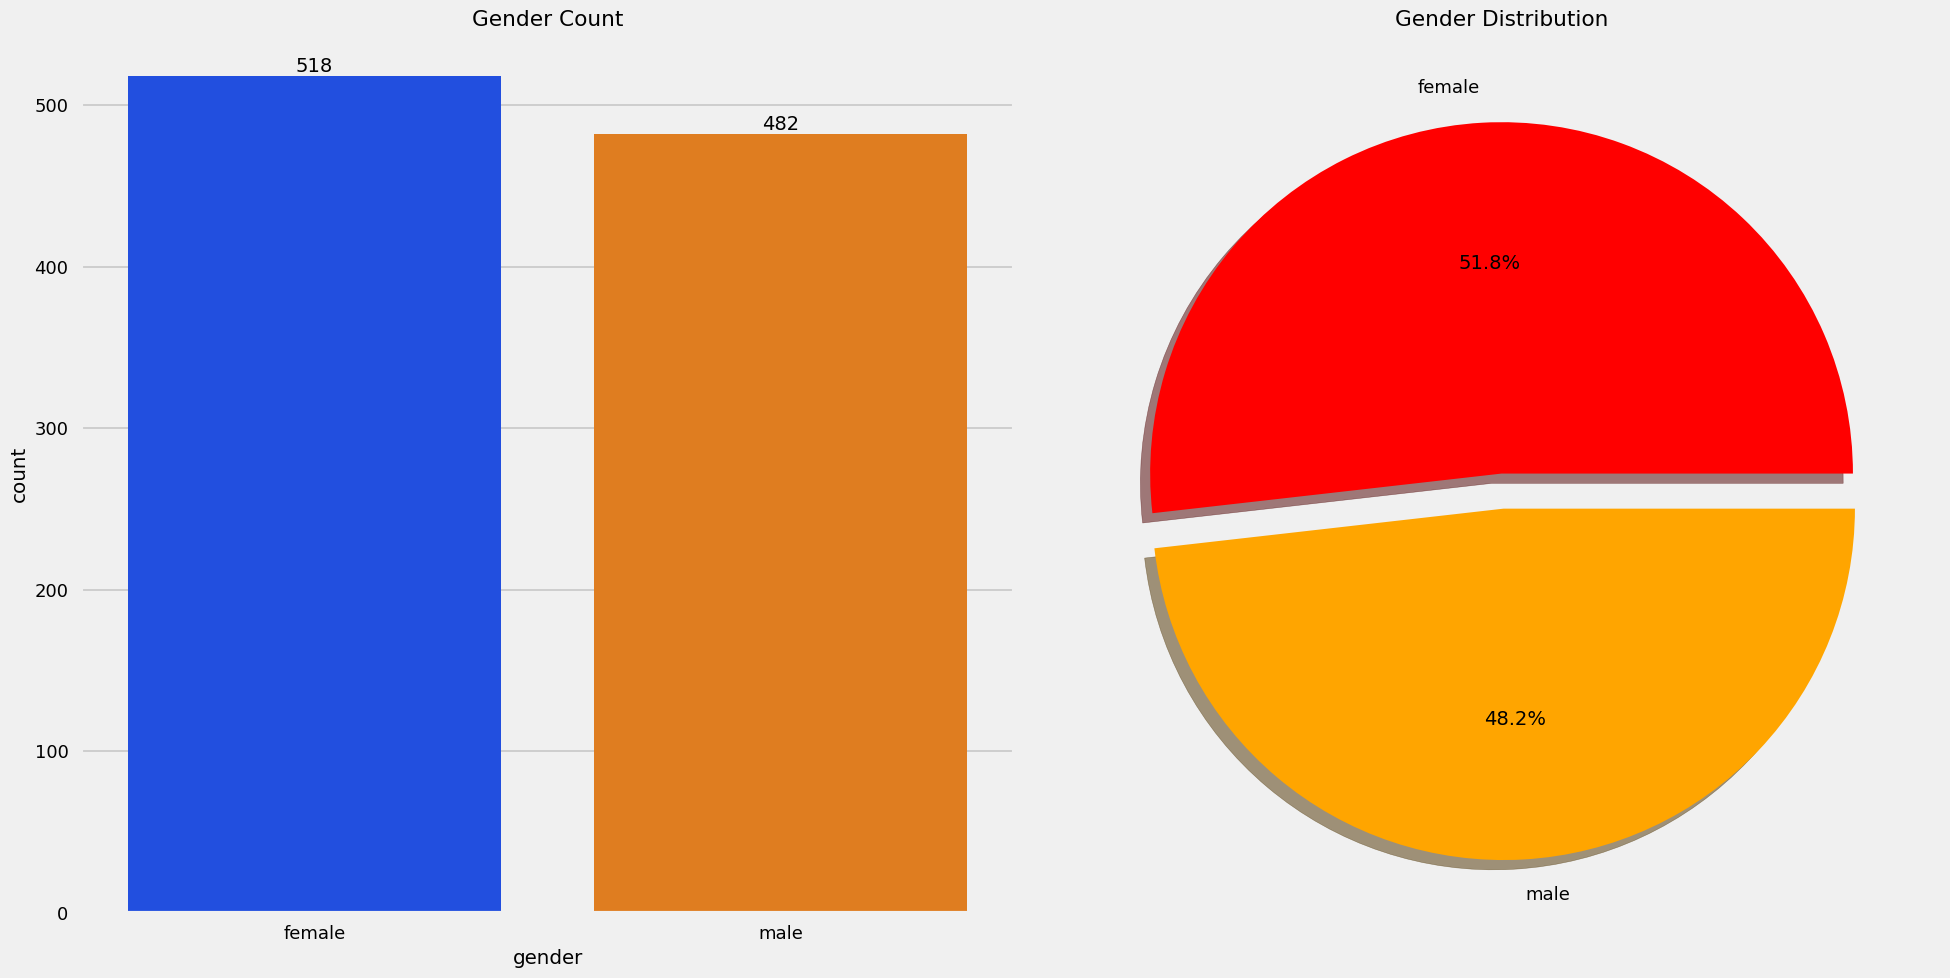

In [79]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

# 🔹 Countplot
sns.countplot(x='gender', data=df, palette='bright', ax=axs[0])

for container in axs[0].containers:
    axs[0].bar_label(container)

axs[0].set_title("Gender Count")

# 🔹 Pie chart
gender_counts = df['gender'].value_counts()

axs[1].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    explode=[0, 0.1],
    shadow=True,
    colors=["red", "orange"]
)

axs[1].set_title("Gender Distribution")

plt.tight_layout()
plt.show()

### Insights
- Gender has balanced data with female students are 518 (51.8%) and male students are 482 (48.2%)

BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [80]:
gender_group=df.groupby("gender")[["average score","math score"]].mean()
gender_group

,average score,math score
gender,,
female,69.569498,63.633205
male,65.837483,68.728216


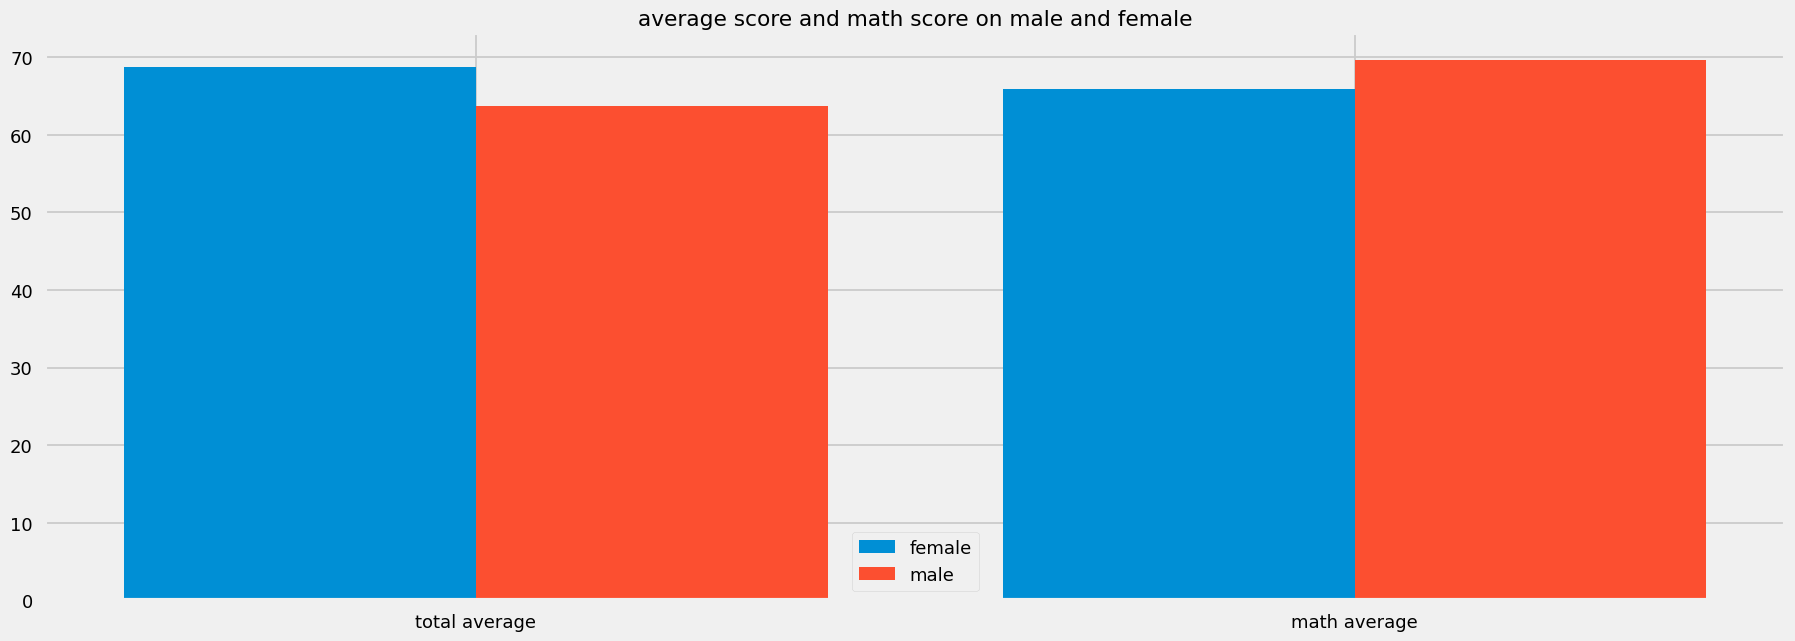

In [81]:
labels=["total average","math average"]

female_scores=[gender_group.loc["female","math score"],gender_group.loc["female","average score"]
]
male_scores=[gender_group.loc["male","math score"],gender_group.loc["male","average score"]]
X_axis=np.arange(len(labels))
plt.figure(figsize=(20,7))
plt.bar(X_axis-0.2,male_scores,width=0.4,label="female")
plt.bar(X_axis+0.2,female_scores,width=0.4,label="male")
plt.xticks(X_axis,labels)
plt.title("average score and math score on male and female")
plt.legend()                            
plt.show()

### Insights
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

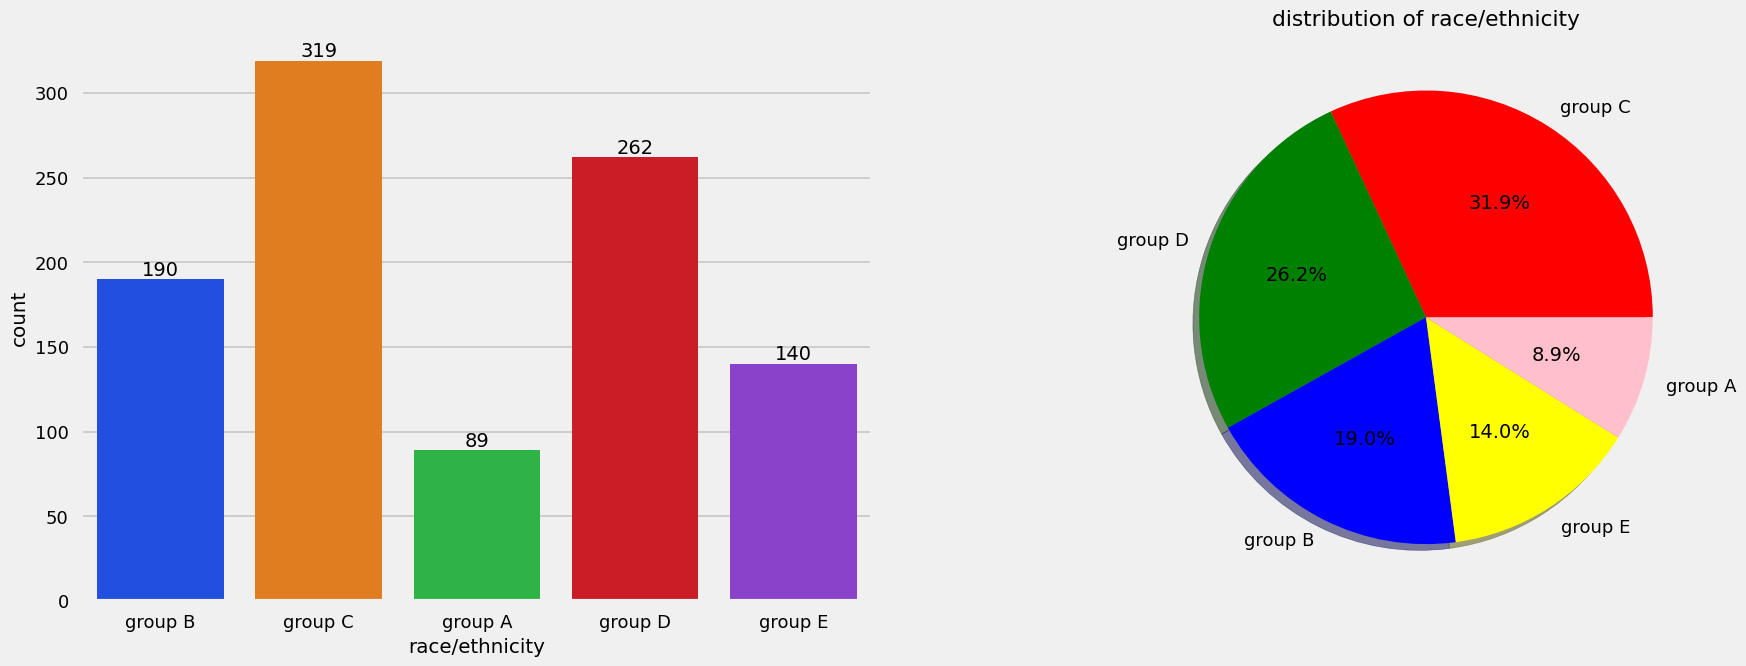

In [82]:
f,axs=plt.subplots(1,2,figsize=(20,7))
sns.countplot(data=df,x="race/ethnicity",palette="bright",ax=axs[0])
for container in axs[0].containers:
    axs[0].bar_label(container)
plt.title("count of race/ethnicity")
plt.pie(x=df["race/ethnicity"].value_counts(),labels=df["race/ethnicity"].value_counts().index,autopct="%1.1f%%",colors=["red","green","blue","yellow","pink"],shadow=True)
plt.title("distribution of race/ethnicity")
plt.show()

### Insights
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

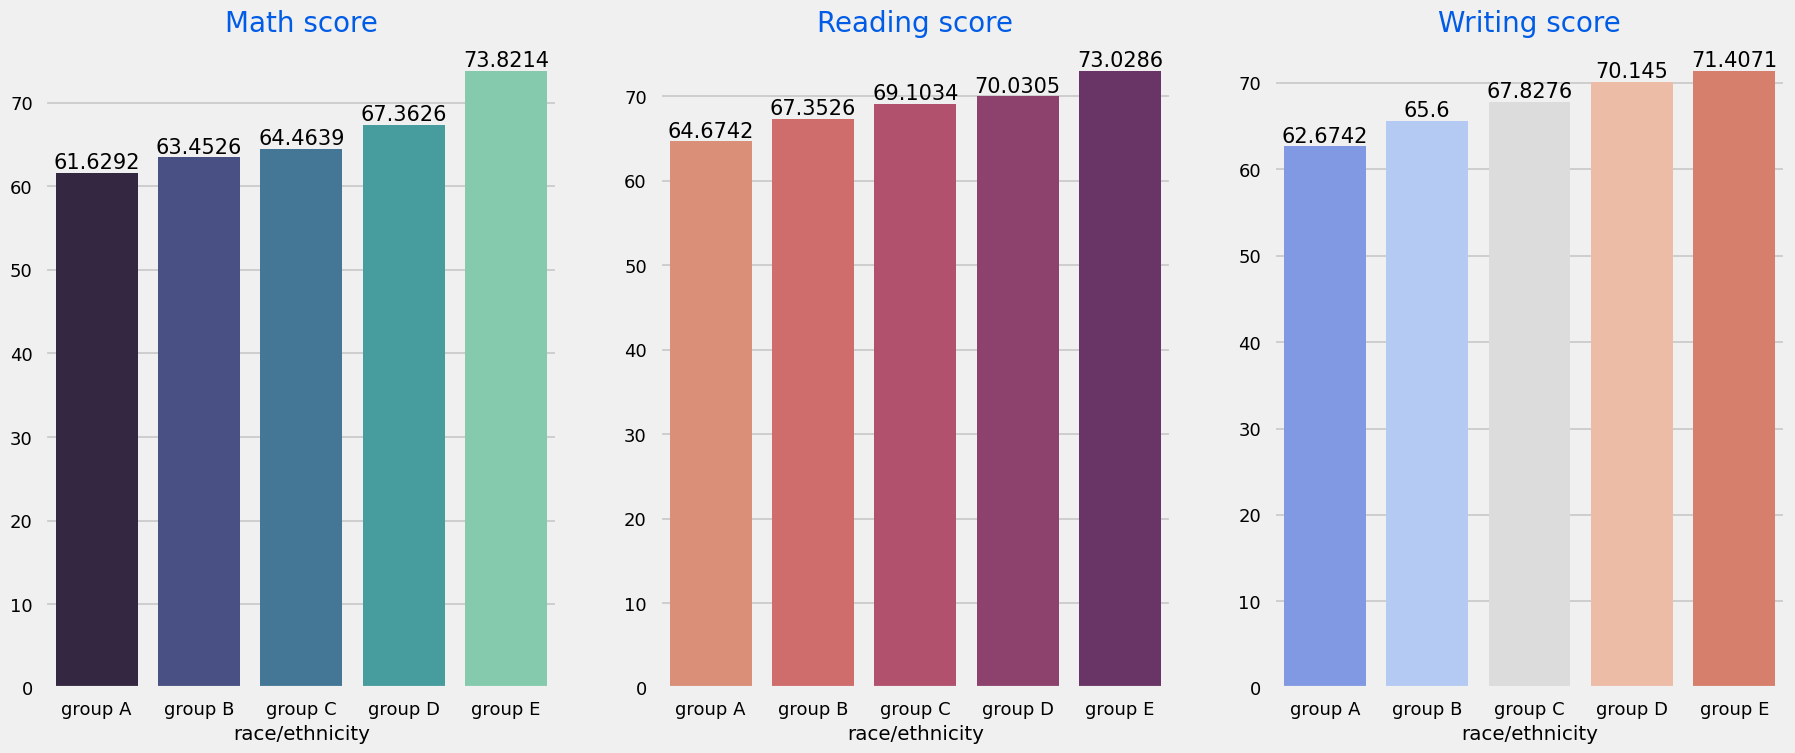

In [83]:
Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

### insights
- Group E students have scored the highest marks.
- Group A students have scored the lowest marks.


PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

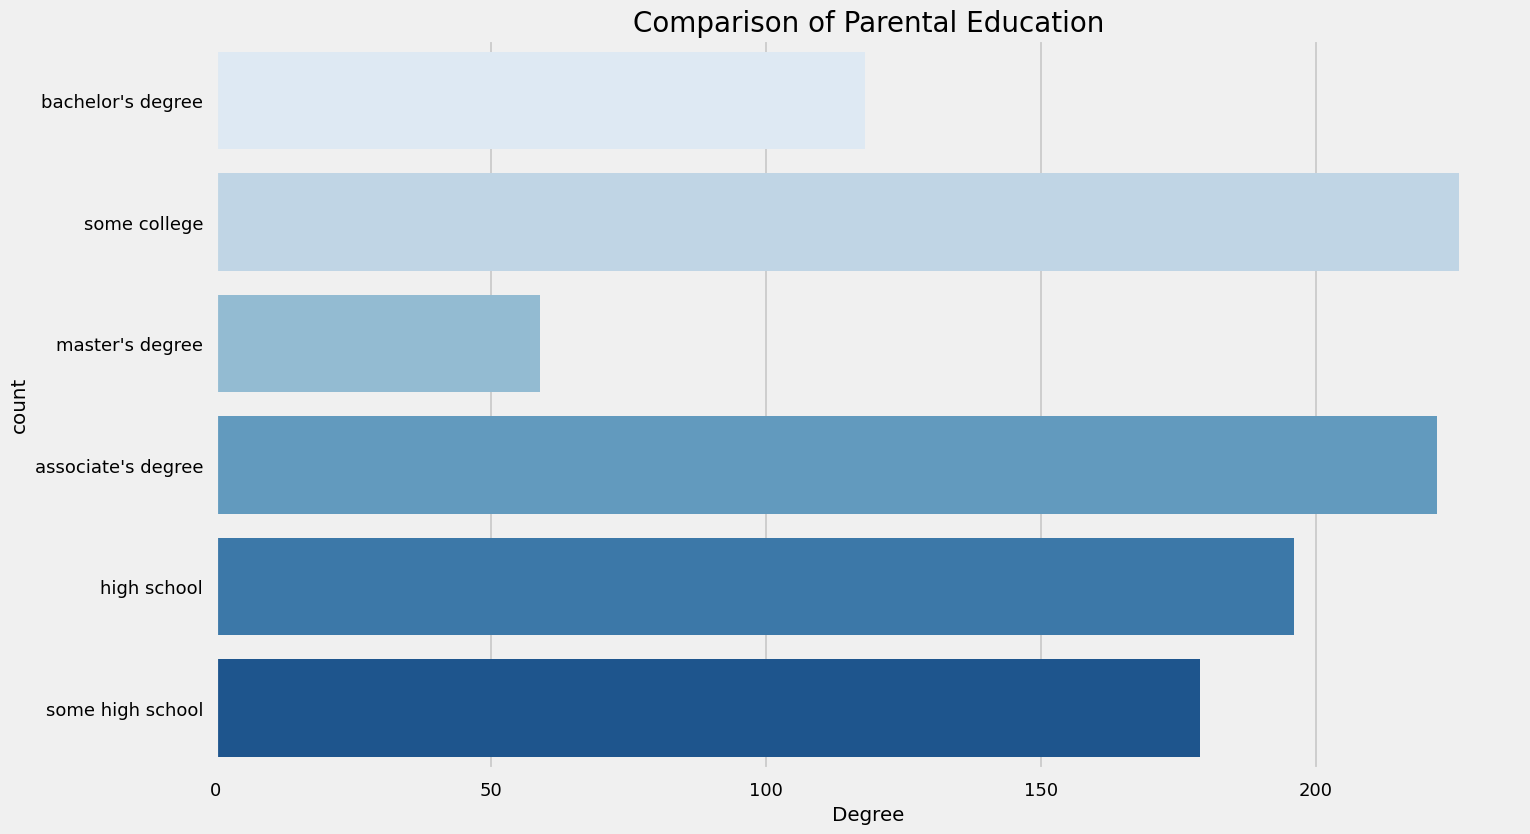

In [84]:
plt.rcParams['figure.figsize'] = (15, 9)
sns.countplot(df['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

### insights
- some college and associate's degree parental level of education students are more
- lower in master's degree

BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

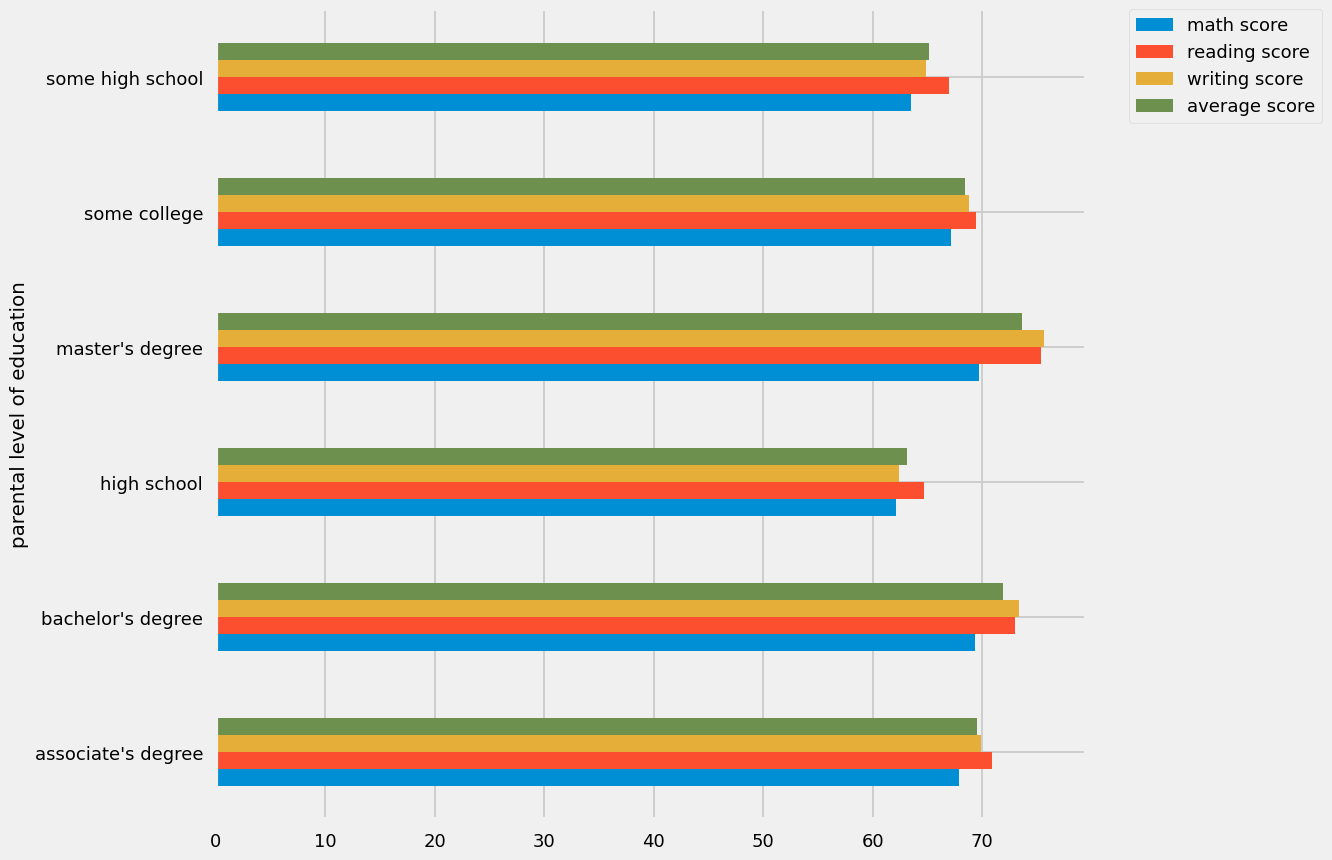

In [85]:
df.groupby('parental level of education')[["math score","reading score","writing score","average score"]].agg('mean').plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

### Insights
- The score of student whose parents possess master and bachelor level education are higher than others.

LUNCH COLUMN
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?

UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

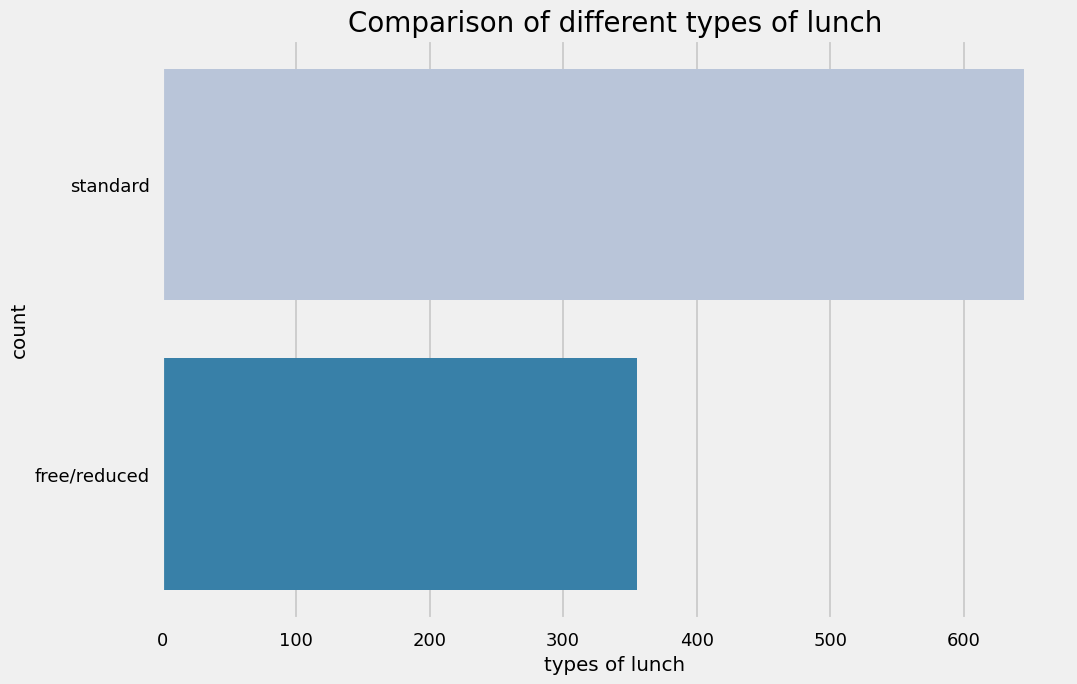

In [86]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

### Insights
- Students being served Standard lunch was more than free lunch

BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

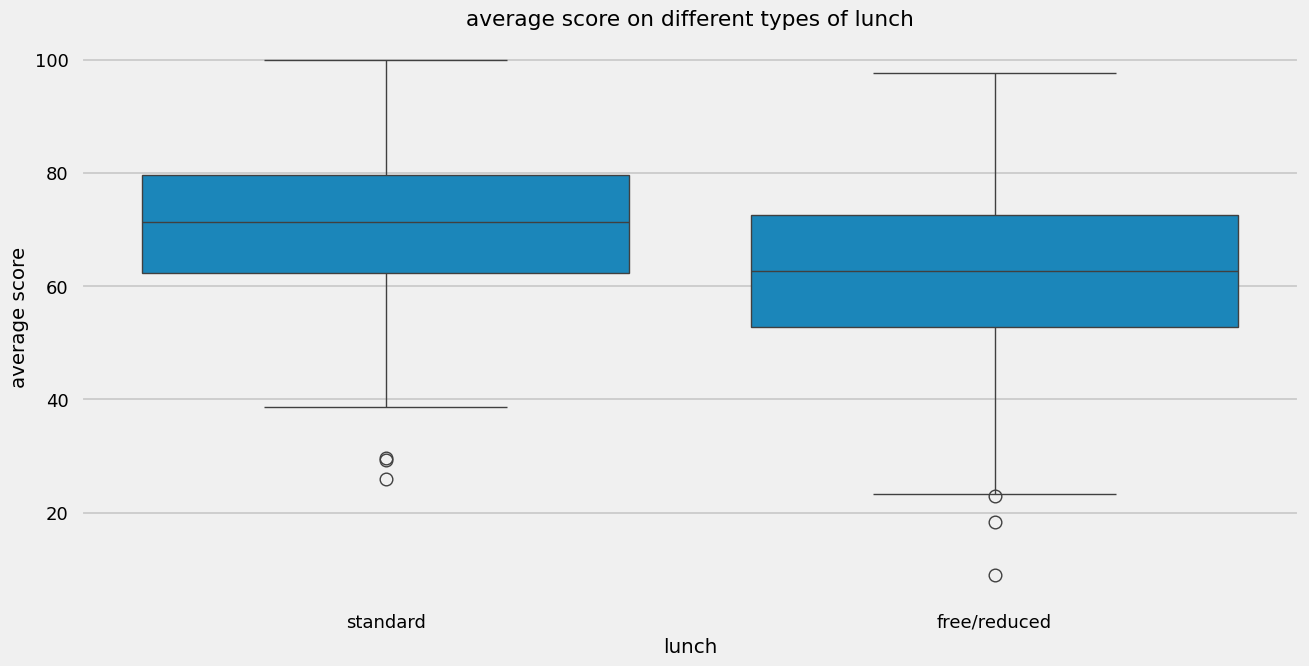

In [88]:
plt.figure(figsize=(14,7))
sns.boxplot(data=df,x="lunch",y="average score")
plt.title("average score on different types of lunch")
plt.show()

### insights
- students taking standard lunch gives  more performance on exam

TEST PREPARATION COURSE COLUMN
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='writing score'>

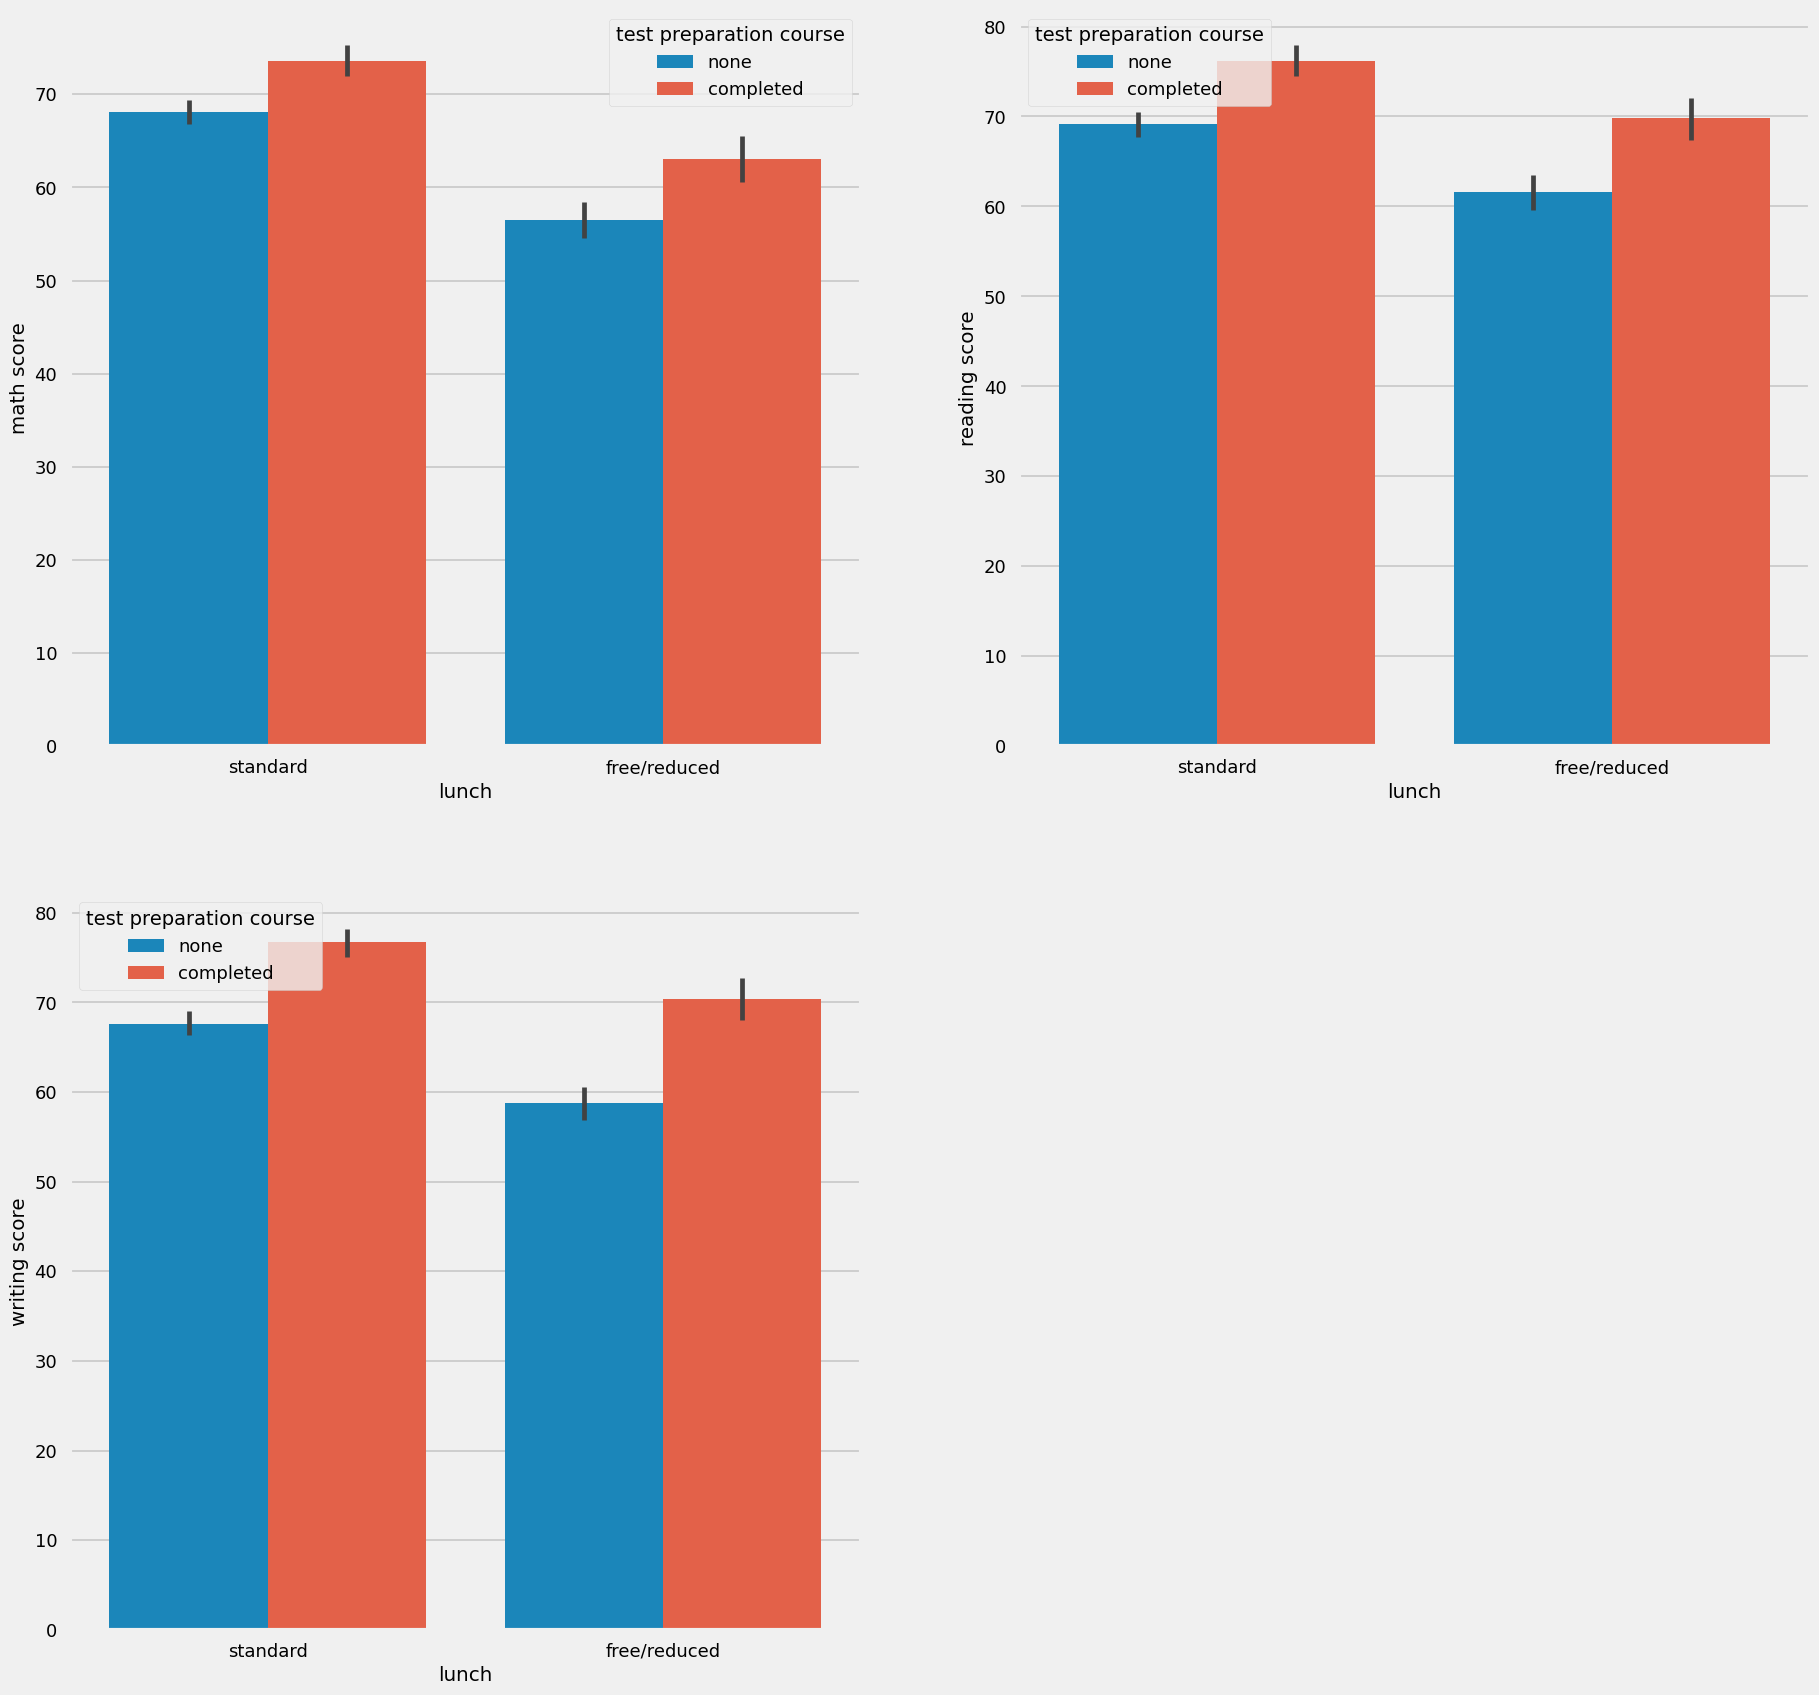

In [90]:
plt.figure(figsize=(20,20))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math score'], hue=df['test preparation course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading score'], hue=df['test preparation course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing score'], hue=df['test preparation course'])

### insights 
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

CHECKING OUTLIERS

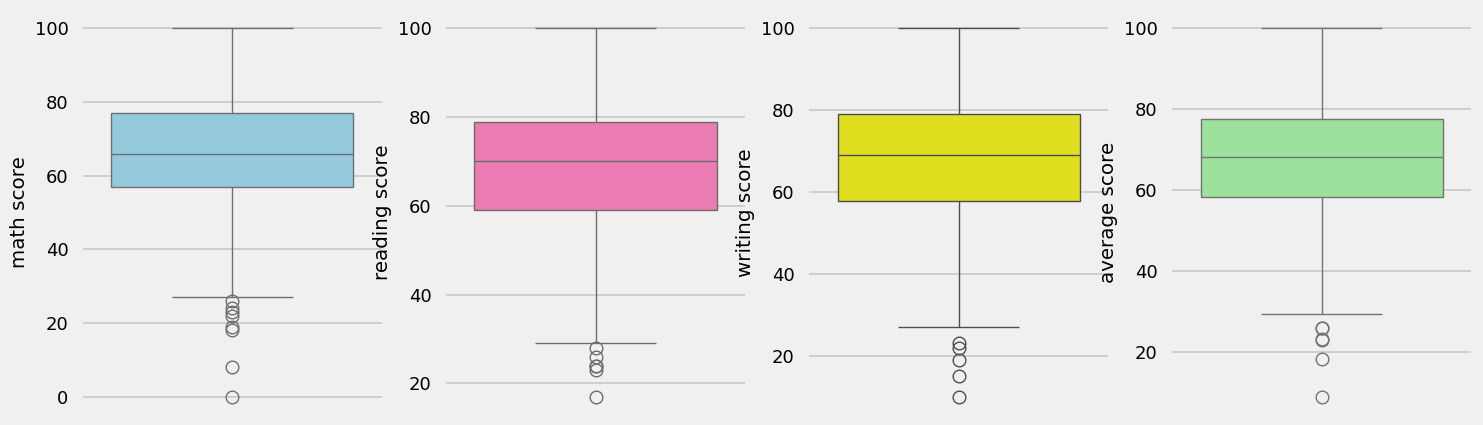

In [92]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average score'],color='lightgreen')
plt.show()

### insights
- in math score one point is actually in 0 ,but it is not an outlier

MUTIVARIATE ANALYSIS USING PAIRPLOT

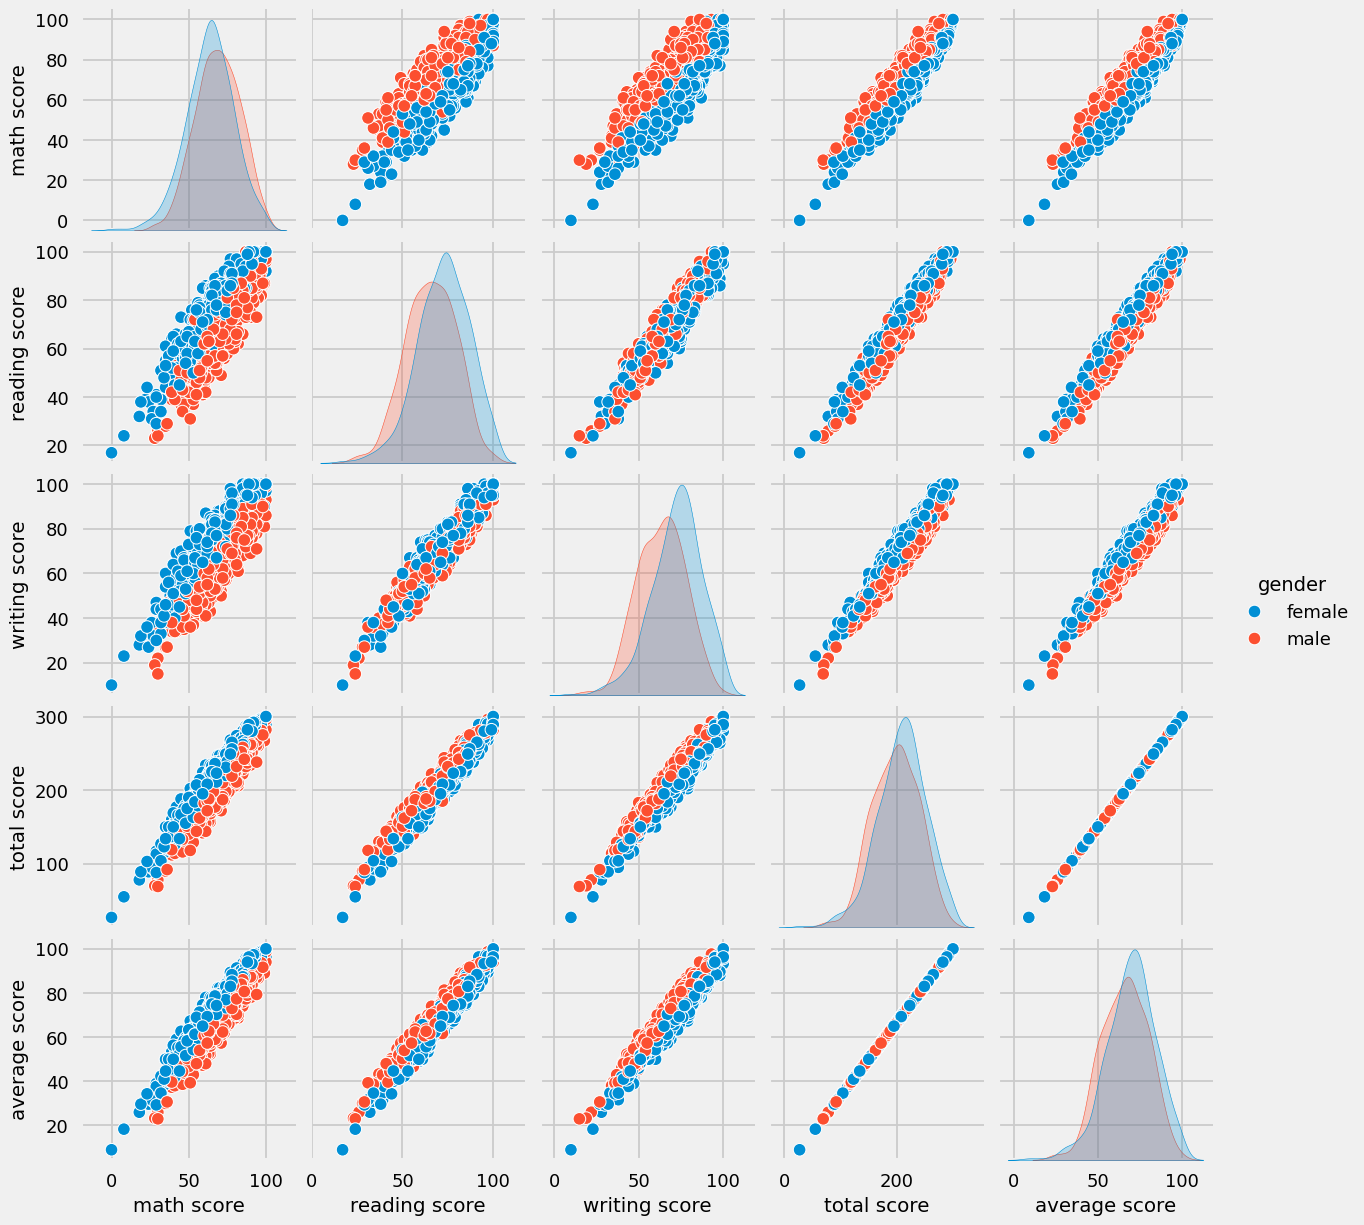

In [93]:
sns.pairplot(df,hue = 'gender')
plt.show()

Insights
From the above plot it is clear that all the scores increase linearly with each other.

### Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.